In [1]:
import pandas as pd
import requests
from astropy.coordinates import Angle
from astropy import units as u
import json
import time

In [2]:
cut_date = 60125 + 2400000.5 - 2458000
url = f'https://sites.astro.caltech.edu/ztf/bts/explorer.php?f=s&subsample=sn&classstring=&classexclude=&quality=y&purity=y&ztflink=lasair&lastdet=&startsavedate=&startpeakdate=&startra=&startdec=&startz=&startdur=&startrise=&startfade=&startpeakmag=&startabsmag=&starthostabs=&starthostcol=&startb=&startav=&endsavedate=&endpeakdate={cut_date}&endra=&enddec=&endz=&enddur=&endrise=&endfade=&endpeakmag=19.0&endabsmag=&endhostabs=&endhostcol=&endb=&endav=&reverse=y&format=csv'
bts = pd.read_csv(url)
bts.to_csv('../data/bts_sample.csv', index=False)

In [3]:
bts = pd.read_csv('bts_sample.csv')

In [ ]:
# get OIDs by coords
# Choose OID with r filter and max N_obs
result_sample = []
t = time.monotonic()
for ra, dec, ztfid, peakfilt in zip(bts['RA'], bts['Dec'], bts['ZTFID'], bts['peakfilt']):
    # Convert RA (in hours) to degrees
    ra = Angle(ra, unit=u.hourangle).degree
    # Convert Dec (in degrees) to degrees
    dec = Angle(dec, unit=u.deg).degree
    # if peakfilt == 'r':
    #     r = 1.5
    # else:
    #     r = 2.5
    r = 2
    try:
        link = f'http://sai.db.ztf.snad.space/api/v3/data/dr23/circle/full/json?ra={ra}&dec={dec}&radius_arcsec={r}'
        with requests.get(link) as response:
            response.raise_for_status()
            data = json.loads(response.content)
    except:
        link = f'http://lpc.db.ztf.snad.space/api/v3/data/dr23/circle/full/json?ra={ra}&dec={dec}&radius_arcsec={r}'
        with requests.get(link) as response:
            response.raise_for_status()
            data = json.loads(response.content)

    
    nobs = 1
    cross = 0
    for oid, inf in data.items():
        if  inf['meta']['filter'] == 'zr' and inf['meta']['nobs'] >= nobs:
            nobs = inf['meta']['nobs']
            cross = [ztfid, oid]
            
    if cross:
        result_sample.append(cross)

print(f'Crossmatched in {int((time.monotonic() - t) / 60)} min')

result = pd.DataFrame(data=result_sample, columns=['ZTFID', 'OID'])
result.to_csv(f'bts_crossmatched_{r}sec.csv', index=False)

In [49]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'days')

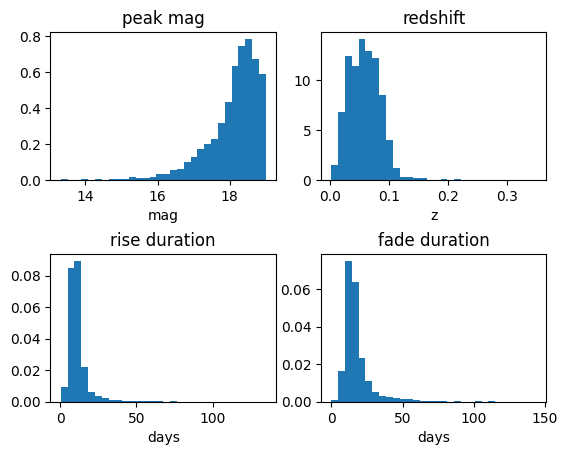

In [65]:
crossmatch = bts[bts['ZTFID'].isin(result['ZTFID'])]
fig, axs = plt.subplots(2,2)
plt.subplots_adjust(hspace=0.5)
_, _, _ = axs[0,0].hist(crossmatch['peakmag'], bins=30, density=True)
_ = axs[0,0].set_title('peak mag')
_ = axs[0,0].set_xlabel('mag')


_, _, _ = axs[0,1].hist(pd.to_numeric(crossmatch['redshift'], errors='coerce'), bins=30, density=True)
axs[0,1].set_title('redshift')
axs[0,1].set_xlabel('z')


rise = pd.to_numeric(crossmatch['rise'], errors='coerce')[pd.to_numeric(crossmatch['rise'], errors='coerce') <= 150]
_, _, _ = axs[1,0].hist(rise, bins=30, density=True)
axs[1,0].set_title('rise duration')
axs[1,0].set_xlabel('days')


fade = pd.to_numeric(crossmatch['fade'], errors='coerce')[pd.to_numeric(crossmatch['fade'], errors='coerce') <= 150]
_, _, _ = axs[1,1].hist(fade, bins=30, density=True)
axs[1,1].set_title('fade duration')
axs[1,1].set_xlabel('days')
